<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Impute Missing Values**


Estimated time needed: **30** minutes


In this lab, you will practice essential data wrangling techniques using the Stack Overflow survey dataset. The primary focus is on handling missing data and ensuring data quality. You will:

- **Load the Data:** Import the dataset into a DataFrame using the pandas library.

- **Clean the Data:** Identify and remove duplicate entries to maintain data integrity.

- **Handle Missing Values:** Detect missing values, impute them with appropriate strategies, and verify the imputation to create a complete and reliable dataset for analysis.

This lab equips you with the skills to effectively preprocess and clean real-world datasets, a crucial step in any data analysis project.


## Objectives


In this lab, you will perform the following:


-   Identify missing values in the dataset.

-   Apply techniques to impute missing values in the dataset.
  
-   Use suitable techniques to normalize data in the dataset.


-----


#### Install needed library


In [25]:
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: C:\Users\Hp\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


### Step 1: Import Required Libraries


In [26]:
import pandas as pd

### Step 2: Load the Dataset Into a Dataframe


#### **Read Data**
<p>
The functions below will download the dataset into your browser:
</p>


In [27]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_path)

# Display the first few rows to ensure it loaded correctly
print(df.head())

   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

### Step 3. Finding and Removing Duplicates
##### Task 1: Identify duplicate rows in the dataset.


In [28]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

df[df.duplicated()].head()

Number of duplicate rows: 0


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat


##### Task 2: Remove the duplicate rows from the dataframe.



In [29]:
df = df.drop_duplicates()

print("Duplicate rows after removal:", df.duplicated().sum())

Duplicate rows after removal: 0


### Step 4: Finding Missing Values
##### Task 3: Find the missing values for all columns.


In [30]:
missing_values = df.isnull().sum()
print("Missing values per column:\n")
print(missing_values)

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values per column:

ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork             10631
                       ...  
JobSatPoints_11        35992
SurveyLength            9255
SurveyEase              9199
ConvertedCompYearly    42002
JobSat                 36311
Length: 114, dtype: int64

Total missing values: 2890957


Null percentages per col


In [ ]:
null_percentage = (df.isnull().sum() / len(df)) * 100

null_percentage.sort_values(ascending=False)

TypeError: Series.sort_values() takes 1 positional argument but 2 positional arguments (and 1 keyword-only argument) were given

Delte cols with > 75% null values

In [11]:
umbral = 0.75

df = df.loc[:, df.isnull().mean() <= umbral]

print(f"Columnas restantes: {df.columns.tolist()}")

Columnas restantes: ['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check', 'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline', 'TechDoc', 'YearsCode', 'YearsCodePro', 'DevType', 'OrgSize', 'PurchaseInfluence', 'BuyNewTool', 'BuildvsBuy', 'TechEndorse', 'Country', 'Currency', 'CompTotal', 'LanguageHaveWorkedWith', 'LanguageWantToWorkWith', 'LanguageAdmired', 'DatabaseHaveWorkedWith', 'DatabaseWantToWorkWith', 'DatabaseAdmired', 'PlatformHaveWorkedWith', 'PlatformWantToWorkWith', 'PlatformAdmired', 'WebframeHaveWorkedWith', 'WebframeWantToWorkWith', 'WebframeAdmired', 'EmbeddedHaveWorkedWith', 'MiscTechHaveWorkedWith', 'MiscTechWantToWorkWith', 'MiscTechAdmired', 'ToolsTechHaveWorkedWith', 'ToolsTechWantToWorkWith', 'ToolsTechAdmired', 'NEWCollabToolsHaveWorkedWith', 'NEWCollabToolsWantToWorkWith', 'NEWCollabToolsAdmired', 'OpSysPersonal use', 'OpSysProfessional use', 'OfficeStackAsyncHaveWorkedWith', 'OfficeStackAsyncWantToWorkWith', 'OfficeStackAsyncAdmired

In [12]:
df.shape

(65437, 108)

##### Task 4: Find out how many rows are missing in the column RemoteWork.


In [13]:
missing_remote = df['RemoteWork'].isnull().sum()
print("Number of missing rows in RemoteWork:", missing_remote)

Number of missing rows in RemoteWork: 10631


### Step 5. Imputing Missing Values
##### Task 5: Find the value counts for the column RemoteWork.


In [14]:
df['RemoteWork'].value_counts(dropna=False)

RemoteWork
Hybrid (some remote, some in-person)    23015
Remote                                  20831
In-person                               10960
NaN                                     10631
Name: count, dtype: int64

##### Task 6: Identify the most frequent (majority) value in the RemoteWork column.



In [15]:
majority_value = df['RemoteWork'].mode()[0]
print("Majority value in RemoteWork:", majority_value)

Majority value in RemoteWork: Hybrid (some remote, some in-person)


##### Task 7: Impute (replace) all the empty rows in the column RemoteWork with the majority value.



In [16]:
df['RemoteWork'].fillna(majority_value, inplace=True)

print("Missing values after imputation:",
      df['RemoteWork'].isnull().sum())

Missing values after imputation: 0


##### Task 8: Check for any compensation-related columns and describe their distribution.



In [17]:
comp_columns = [col for col in df.columns if 'Comp' in col]
print("Compensation-related columns:", comp_columns)

Compensation-related columns: ['CompTotal', 'AIComplex', 'ConvertedCompYearly']


In [18]:
df[comp_columns].describe()

,CompTotal,ConvertedCompYearly
count,3.374000e+04,2.343500e+04
mean,2.963841e+145,8.615529e+04
std,5.444117e+147,1.867570e+05
min,0.000000e+00,1.000000e+00
25%,6.000000e+04,3.271200e+04
50%,1.100000e+05,6.500000e+04
75%,2.500000e+05,1.079715e+05
max,1.000000e+150,1.625660e+07


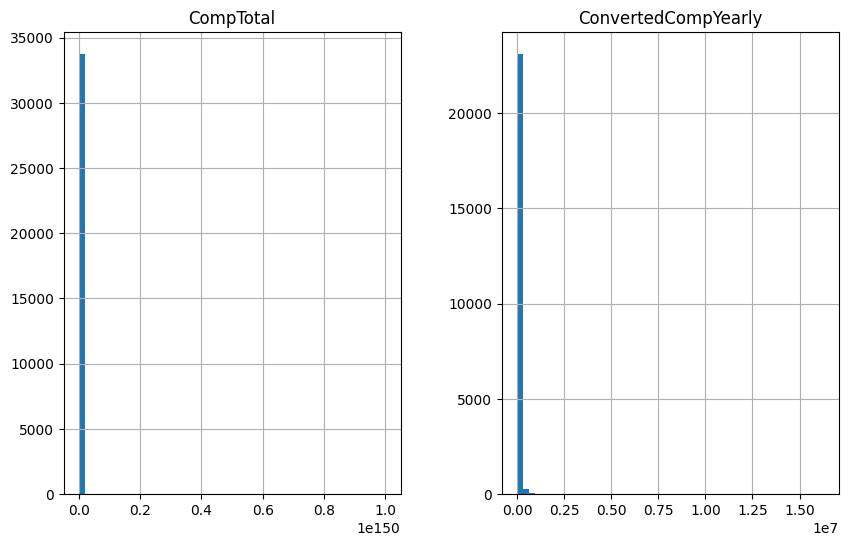

In [19]:
import matplotlib.pyplot as plt

df[comp_columns].hist(figsize=(10,6), bins=50)
plt.show()

Median input in numeric columns


In [20]:
cols_numericas = df.select_dtypes(include=['number']).columns

df[cols_numericas] = df[cols_numericas].fillna(df[cols_numericas].median())

print(f"Numeric cols imput: {list(cols_numericas)}")

Numeric cols imput: ['ResponseId', 'CompTotal', 'WorkExp', 'JobSatPoints_1', 'JobSatPoints_4', 'JobSatPoints_5', 'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9', 'JobSatPoints_10', 'JobSatPoints_11', 'ConvertedCompYearly', 'JobSat']


Categorical cols

In [21]:
cols_categoricas = df.select_dtypes(exclude=['number']).columns
print(f"Columnas pendientes (categóricas): {list(cols_categoricas)}")

Columnas pendientes (categóricas): ['MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check', 'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline', 'TechDoc', 'YearsCode', 'YearsCodePro', 'DevType', 'OrgSize', 'PurchaseInfluence', 'BuyNewTool', 'BuildvsBuy', 'TechEndorse', 'Country', 'Currency', 'LanguageHaveWorkedWith', 'LanguageWantToWorkWith', 'LanguageAdmired', 'DatabaseHaveWorkedWith', 'DatabaseWantToWorkWith', 'DatabaseAdmired', 'PlatformHaveWorkedWith', 'PlatformWantToWorkWith', 'PlatformAdmired', 'WebframeHaveWorkedWith', 'WebframeWantToWorkWith', 'WebframeAdmired', 'EmbeddedHaveWorkedWith', 'MiscTechHaveWorkedWith', 'MiscTechWantToWorkWith', 'MiscTechAdmired', 'ToolsTechHaveWorkedWith', 'ToolsTechWantToWorkWith', 'ToolsTechAdmired', 'NEWCollabToolsHaveWorkedWith', 'NEWCollabToolsWantToWorkWith', 'NEWCollabToolsAdmired', 'OpSysPersonal use', 'OpSysProfessional use', 'OfficeStackAsyncHaveWorkedWith', 'OfficeStackAsyncWantToWorkWith', 'OfficeStackAsyncAdmired', 'OfficeSt

In [23]:
umbral_moda = 0.60

for col in cols_categoricas:
    frecuencias = df[col].value_counts(normalize=True)
    
    if not frecuencias.empty:
        moda_valor = frecuencias.index[0]
        moda_porcentaje = frecuencias.iloc[0]
        
        if moda_porcentaje >= umbral_moda:
            df[col] = df[col].fillna(moda_valor)
            print(f"Columna '{col}': Imputada con moda '{moda_valor}' ({moda_porcentaje:.2%})")
        else:
            df[col] = df[col].fillna('Unknown')
            print(f"Columna '{col}': Imputada con 'Unknown' (Moda débil: {moda_porcentaje:.2%})")
    else:
        df[col] = df[col].fillna('Unknown')

Columna 'MainBranch': Imputada con moda 'I am a developer by profession' (76.73%)
Columna 'Age': Imputada con 'Unknown' (Moda débil: 36.54%)
Columna 'Employment': Imputada con 'Unknown' (Moda débil: 59.66%)
Columna 'RemoteWork': Imputada con 'Unknown' (Moda débil: 51.42%)
Columna 'Check': Imputada con moda 'Apples' (100.00%)
Columna 'CodingActivities': Imputada con 'Unknown' (Moda débil: 18.35%)
Columna 'EdLevel': Imputada con 'Unknown' (Moda débil: 41.03%)
Columna 'LearnCode': Imputada con 'Unknown' (Moda débil: 6.07%)
Columna 'LearnCodeOnline': Imputada con 'Unknown' (Moda débil: 1.22%)
Columna 'TechDoc': Imputada con 'Unknown' (Moda débil: 16.99%)
Columna 'YearsCode': Imputada con 'Unknown' (Moda débil: 7.62%)
Columna 'YearsCodePro': Imputada con 'Unknown' (Moda débil: 8.08%)
Columna 'DevType': Imputada con 'Unknown' (Moda débil: 30.72%)
Columna 'OrgSize': Imputada con 'Unknown' (Moda débil: 20.54%)
Columna 'PurchaseInfluence': Imputada con 'Unknown' (Moda débil: 40.49%)
Columna 'Bu

Save csv

In [24]:
df.to_csv('./cleaned_data/imputed_dataset.csv', index=False, encoding='utf-8')

### Summary 


**In this lab, you focused on imputing missing values in the dataset.**

- Use the <code>pandas.read_csv()</code> function to load a dataset from a CSV file into a DataFrame.

- Download the dataset if it's not available online and specify the correct file path.



<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-11-05|1.3|Madhusudhan Moole|Updated lab|
|2024-10-29|1.2|Madhusudhan Moole|Updated lab|
|2024-09-27|1.1|Madhusudhan Moole|Updated lab|
|2024-09-26|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
